# 🏦 OnePilot — Forecasting | Notebook 7 : SXA Trésorerie
**Source** : SXA — [Transactions bancaires]  
**Cible** : Flux net hebdomadaire (TND)  
**Données** : 78 semaines (2024-01 → 2025-06)

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import logging, warnings
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '85a0ef4b-d9af-494f-b24f-ff710c21ba43'
device     = 'cuda' if torch.cuda.is_available() else 'cpu'

plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor':   '#182336', 'text.color':     '#d8e8f2',
    'axes.labelcolor':  '#7ea4be', 'xtick.color':    '#7ea4be',
    'ytick.color':      '#7ea4be', 'grid.color':     '#182336',
    'grid.linestyle':   '--',      'grid.alpha':     0.5
})
print(f'✅ Imports OK | device={device}')

✅ Imports OK | device=cpu


In [2]:
# ── Extraction SXA ────────────────────────────────────────────────
def run_sql(sql, source_id=SOURCE_SXA, limit=10000):
    resp = requests.post(f'{BASE_URL}/dashboard/data',
                         json={'sql': sql, 'source_id': source_id, 'limit': limit},
                         timeout=60)
    data = resp.json()
    if 'rows' not in data:
        raise Exception(data)
    return pd.DataFrame(data['rows'])

df_sxa = run_sql("""
    SELECT
        YEAR(TRNDATE) AS annee,
        DATEPART(WEEK, TRNDATE) AS semaine,
        MIN(TRNDATE) AS date_debut,
        SUM([montant avec signe]) AS flux_net,
        SUM(CASE WHEN ISDEBIT=0 THEN AMOUNT ELSE 0 END) AS entrees,
        SUM(CASE WHEN ISDEBIT=1 THEN AMOUNT ELSE 0 END) AS sorties,
        COUNT(*) AS nb_transactions
    FROM [Transactions bancaires]
    GROUP BY YEAR(TRNDATE), DATEPART(WEEK, TRNDATE)
    ORDER BY annee, semaine
""")

df_sxa['date'] = pd.to_datetime(df_sxa['date_debut'])
df_sxa = df_sxa.set_index('date').sort_index()
df_sxa['flux_net'] = pd.to_numeric(df_sxa['flux_net'])
series = df_sxa['flux_net']

print(f'✅ Données SXA extraites')
print(f'   Semaines       : {len(series)}')
print(f'   Période        : {series.index.min().strftime("%Y-%m-%d")} → {series.index.max().strftime("%Y-%m-%d")}')
print(f'   Flux net moyen : {series.mean():,.0f} TND')
print(f'   Min / Max      : {series.min():,.0f} / {series.max():,.0f} TND')
print(f'   Valeurs négatives : {(series < 0).sum()}/{len(series)} semaines')

✅ Données SXA extraites
   Semaines       : 78
   Période        : 2024-01-02 → 2025-06-16
   Flux net moyen : -8,615 TND
   Min / Max      : -432,243 / 354,857 TND
   Valeurs négatives : 41/78 semaines


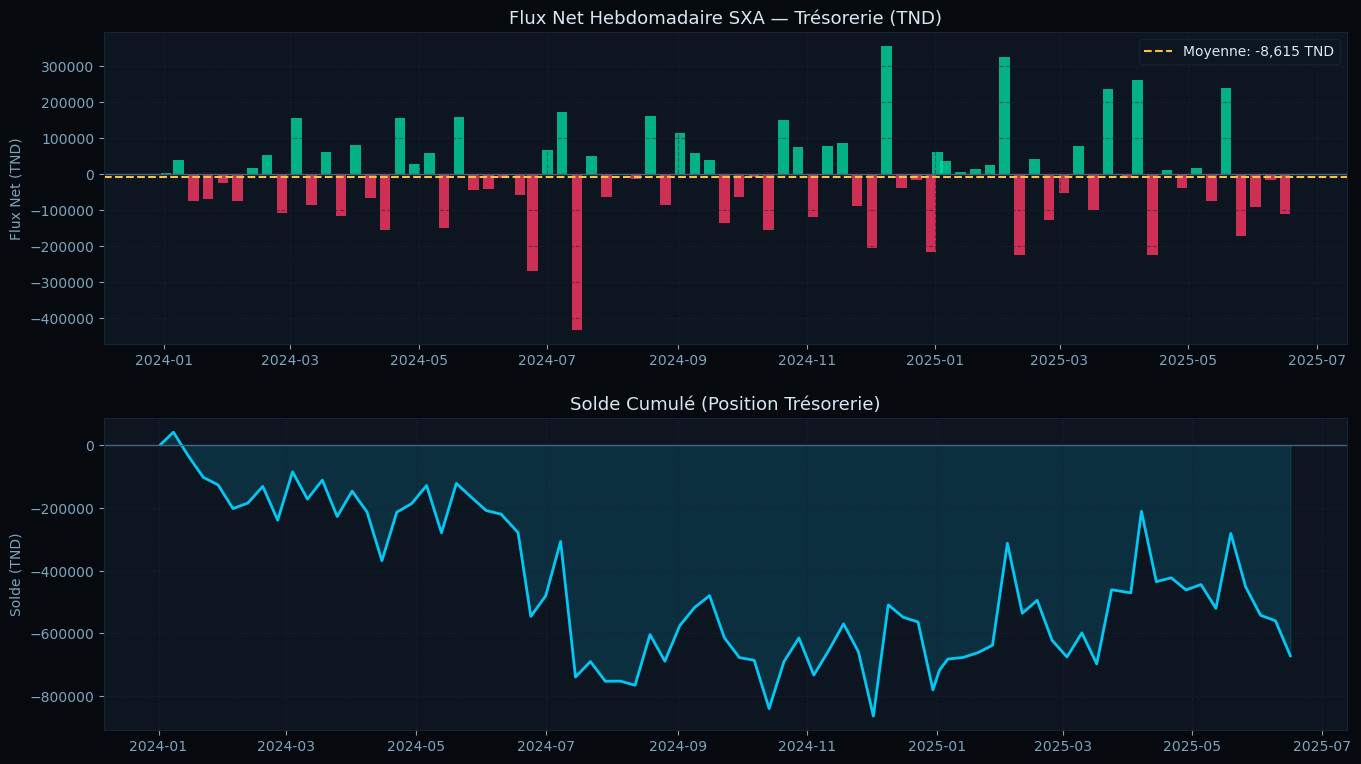

✅ Graphique sauvegardé


In [3]:
# ── Visualisation de la série SXA ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Flux net hebdomadaire
ax1 = axes[0]
colors = ['#00d9a0' if v >= 0 else '#ff3663' for v in series.values]
ax1.bar(series.index, series.values, color=colors, width=5, alpha=0.8)
ax1.axhline(0, color='#45657e', linestyle='-', lw=1)
ax1.axhline(series.mean(), color='#ffbf40', linestyle='--', lw=1.5,
            label=f'Moyenne: {series.mean():,.0f} TND')
ax1.set_title('Flux Net Hebdomadaire SXA — Trésorerie (TND)', color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Flux Net (TND)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax1.grid(True)

# Solde cumulé (position de trésorerie)
ax2 = axes[1]
solde_cumule = series.cumsum()
ax2.plot(solde_cumule.index, solde_cumule.values, color='#00c8f5', lw=2)
ax2.fill_between(solde_cumule.index, solde_cumule.values, alpha=0.15, color='#00c8f5')
ax2.axhline(0, color='#45657e', linestyle='-', lw=1)
ax2.set_title('Solde Cumulé (Position Trésorerie)', color='#d8e8f2', fontsize=13)
ax2.set_ylabel('Solde (TND)', color='#7ea4be')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.grid(True)

plt.tight_layout(pad=2)
plt.savefig('/tmp/sxa_series.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé')

In [4]:
# ── Split Train/Test ──────────────────────────────────────────────
split = int(len(series) * 0.8)
train, test = series.iloc[:split], series.iloc[split:]
n_test    = len(test)
n_horizon = 12
n_total   = n_test + n_horizon

print(f'✅ Split 80/20')
print(f'   Train : {len(train)} semaines ({train.index.min().strftime("%Y-%m-%d")} → {train.index.max().strftime("%Y-%m-%d")})')
print(f'   Test  : {len(test)} semaines ({test.index.min().strftime("%Y-%m-%d")} → {test.index.max().strftime("%Y-%m-%d")})')

✅ Split 80/20
   Train : 62 semaines (2024-01-02 → 2025-02-24)
   Test  : 16 semaines (2025-03-03 → 2025-06-16)


In [9]:
from statsmodels.tsa.arima.model import ARIMA as SM_ARIMA

print('1️⃣  SARIMA (non-saisonnier sur SXA — données insuffisantes pour s=52)...')

# auto_arima sans saisonnalité
sarima_m = auto_arima(
    train, seasonal=False,
    d=None, stepwise=True,
    max_p=3, max_q=3,
    information_criterion='aic',
    suppress_warnings=True, error_action='ignore', trace=False
)

# Prévision via statsmodels directement (plus robuste sur séries volatiles)
sm_model = SM_ARIMA(train.values, order=sarima_m.order).fit()
fc_result = sm_model.get_forecast(n_total)
sarima_fc  = fc_result.predicted_mean
sarima_ci  = fc_result.conf_int(alpha=0.05)

# Remplacer les éventuels NaN résiduels
sarima_fc = np.where(np.isnan(sarima_fc), train.mean(), sarima_fc)
std_train = train.std()
sarima_ci[np.isnan(sarima_ci[:,0]), 0] = sarima_fc[np.isnan(sarima_ci[:,0])] - std_train
sarima_ci[np.isnan(sarima_ci[:,1]), 1] = sarima_fc[np.isnan(sarima_ci[:,1])] + std_train

mae_sarima = mean_absolute_error(test, sarima_fc[:n_test])
print(f'   ARIMA{sarima_m.order} — MAE: {mae_sarima:,.0f} TND')

1️⃣  SARIMA (non-saisonnier sur SXA — données insuffisantes pour s=52)...
   ARIMA(0, 0, 1) — MAE: 108,888 TND


In [10]:
# ══════════════════════════════════════════════════════════════════
# MODÈLE 2 — Prophet
# ══════════════════════════════════════════════════════════════════
print('2️⃣  Prophet...')
df_p = pd.DataFrame({'ds': train.index, 'y': train.values})
prophet_m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,  # plus flexible pour données volatiles
    seasonality_mode='additive',
    interval_width=0.95
)
prophet_m.fit(df_p)
future_p   = prophet_m.make_future_dataframe(periods=n_total, freq='W')
fc_p       = prophet_m.predict(future_p)
fc_p_fut   = fc_p[fc_p['ds'] > train.index[-1]].head(n_total)
prophet_fc = fc_p_fut['yhat'].values
prophet_lo = fc_p_fut['yhat_lower'].values
prophet_hi = fc_p_fut['yhat_upper'].values
mae_prophet = mean_absolute_error(test, prophet_fc[:n_test])
print(f'   Prophet — MAE: {mae_prophet:,.0f} TND')

00:20:58 - cmdstanpy - INFO - Chain [1] start processing
00:20:58 - cmdstanpy - INFO - Chain [1] done processing


2️⃣  Prophet...
   Prophet — MAE: 116,552 TND


In [11]:
# ══════════════════════════════════════════════════════════════════
# MODÈLE 3 — LSTM (MinMaxScaler adapté aux valeurs négatives)
# ══════════════════════════════════════════════════════════════════
print('3️⃣  LSTM...')
WINDOW = 8

class LSTMForecaster(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers,
                            dropout=dropout if layers>1 else 0, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# feature_range=(-1,1) pour gérer les valeurs négatives
scaler = MinMaxScaler(feature_range=(-1, 1))
train_sc = scaler.fit_transform(train.values.reshape(-1,1)).flatten()

X_lst, y_lst = [], []
for i in range(len(train_sc)-WINDOW):
    X_lst.append(train_sc[i:i+WINDOW])
    y_lst.append(train_sc[i+WINDOW])

X_t = torch.FloatTensor(np.array(X_lst)).unsqueeze(-1).to(device)
y_t = torch.FloatTensor(np.array(y_lst)).to(device)

lstm_m  = LSTMForecaster().to(device)
opt     = torch.optim.Adam(lstm_m.parameters(), lr=0.001)
crit    = nn.MSELoss()
loader  = torch.utils.data.DataLoader(
              torch.utils.data.TensorDataset(X_t, y_t), batch_size=16, shuffle=True)

for epoch in range(150):
    lstm_m.train()
    for xb, yb in loader:
        opt.zero_grad()
        loss = crit(lstm_m(xb), yb)
        loss.backward()
        opt.step()
    if (epoch+1) % 50 == 0:
        print(f'   Epoch {epoch+1}/150 — Loss: {loss.item():.6f}')

lstm_m.eval()
win = list(train_sc[-WINDOW:])
preds_sc = []
with torch.no_grad():
    for _ in range(n_total):
        x_in = torch.FloatTensor(win[-WINDOW:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = lstm_m(x_in).item()
        preds_sc.append(pred)
        win.append(pred)

# Clip dans [-1,1] avant inverse_transform (feature_range=(-1,1))
preds_sc_clipped = np.clip(preds_sc, -1, 1)
lstm_fc = scaler.inverse_transform(np.array(preds_sc_clipped).reshape(-1,1)).flatten()
mae_lstm = mean_absolute_error(test, lstm_fc[:n_test])
print(f'   LSTM — MAE: {mae_lstm:,.0f} TND')

3️⃣  LSTM...
   Epoch 50/150 — Loss: 0.178207
   Epoch 100/150 — Loss: 0.014850
   Epoch 150/150 — Loss: 0.016097
   LSTM — MAE: 94,907 TND


In [12]:
# ══════════════════════════════════════════════════════════════════
# ENSEMBLE 7 COMBINAISONS
# ══════════════════════════════════════════════════════════════════
s, p, l = sarima_fc[:n_test], prophet_fc[:n_test], lstm_fc[:n_test]
y = test.values

combos = {
    'SARIMA':              s,
    'Prophet':             p,
    'LSTM':                l,
    'SARIMA+Prophet':      (s+p)/2,
    'SARIMA+LSTM':         (s+l)/2,
    'Prophet+LSTM':        (p+l)/2,
    'SARIMA+Prophet+LSTM': (s+p+l)/3,
}
maes = {k: mean_absolute_error(y, v) for k, v in combos.items()}
best = min(maes, key=maes.get)

df_rank = pd.DataFrame([
    {'Combinaison': k, 'MAE_TND': f"{v:,.0f}"}
    for k, v in sorted(maes.items(), key=lambda x: x[1])
])

print('='*50)
print('  CLASSEMENT SXA — 7 COMBINAISONS')
print('='*50)
for _, row in df_rank.iterrows():
    badge = ' ← SÉLECTIONNÉ ✅' if row['Combinaison'] == best else ''
    print(f"  {row['Combinaison']:<25} MAE: {row['MAE_TND']} TND{badge}")
print(f'\n  Meilleur : {best} — MAE: {maes[best]:,.0f} TND')

  CLASSEMENT SXA — 7 COMBINAISONS
  LSTM                      MAE: 94,907 TND ← SÉLECTIONNÉ ✅
  SARIMA+LSTM               MAE: 99,725 TND
  Prophet+LSTM              MAE: 101,457 TND
  SARIMA+Prophet+LSTM       MAE: 103,003 TND
  SARIMA                    MAE: 108,888 TND
  SARIMA+Prophet            MAE: 109,207 TND
  Prophet                   MAE: 116,552 TND

  Meilleur : LSTM — MAE: 94,907 TND


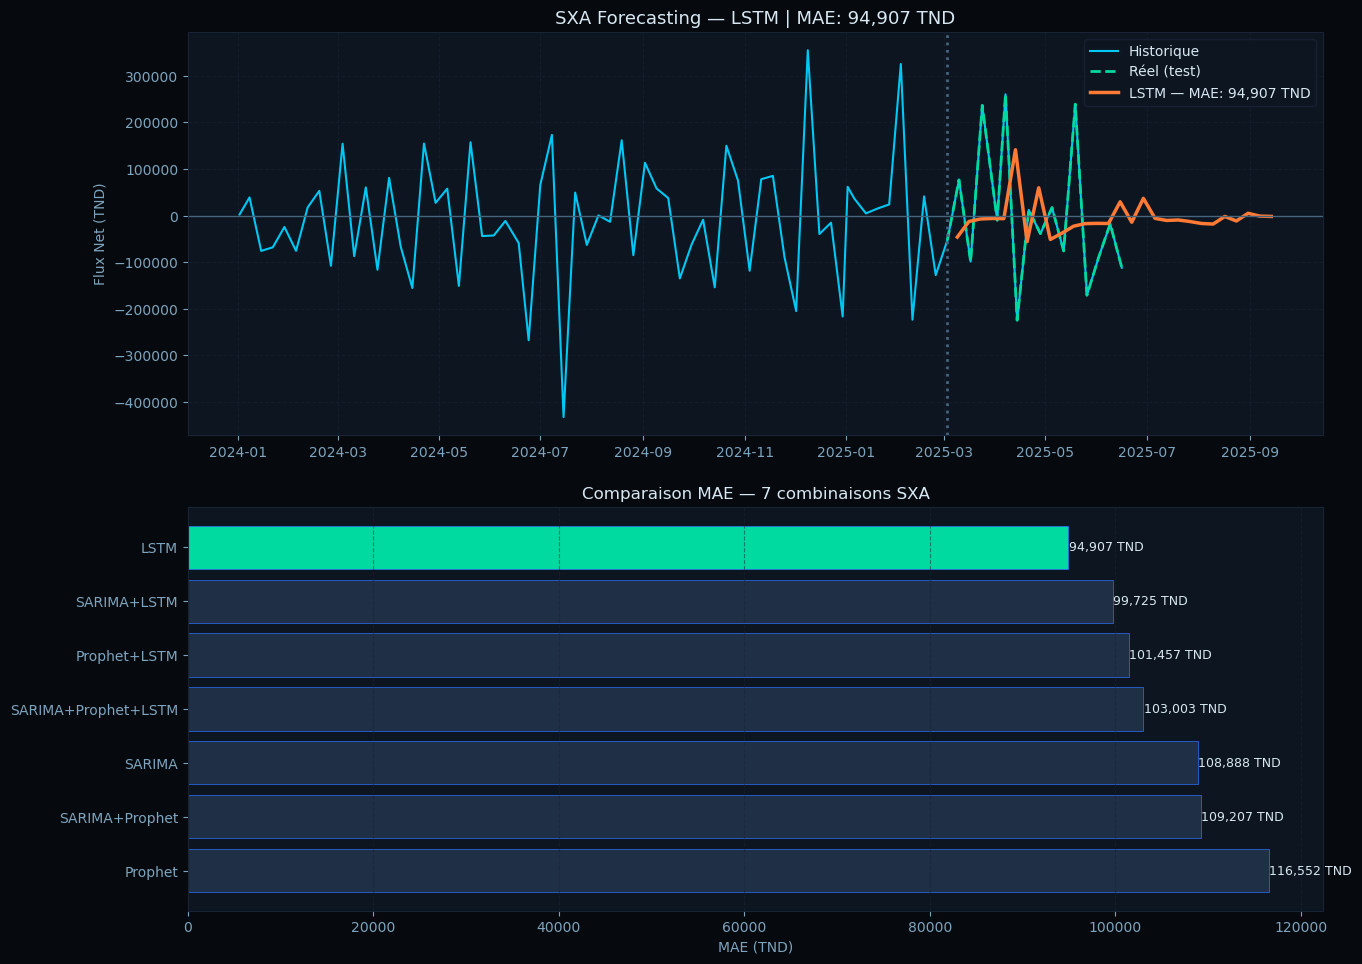

✅ Graphique sauvegardé → /tmp/sxa_forecast.png


In [13]:
# ── Prévisions finales + visualisation ───────────────────────────
models_in = best.split('+')
fc_arrays = []
if 'SARIMA'  in models_in: fc_arrays.append(sarima_fc)
if 'Prophet' in models_in: fc_arrays.append(prophet_fc)
if 'LSTM'    in models_in: fc_arrays.append(lstm_fc)
best_fc = np.mean(fc_arrays, axis=0)

future_idx = pd.date_range(
    start=train.index[-1] + pd.Timedelta(weeks=1),
    periods=n_total, freq='W'
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 — Prévision flux net
ax1 = axes[0]
ax1.plot(series.index, series.values, color='#00c8f5', lw=1.5, label='Historique')
ax1.plot(test.index, test.values, color='#00d9a0', lw=2, linestyle='--', label='Réel (test)')
ax1.plot(future_idx, best_fc, color='#ff7a35', lw=2.5, label=f'{best} — MAE: {maes[best]:,.0f} TND')
ax1.axhline(0, color='#45657e', linestyle='-', lw=1)
ax1.axvline(x=test.index[0], color='#45657e', linestyle=':', lw=2)
ax1.set_title(f'SXA Forecasting — {best} | MAE: {maes[best]:,.0f} TND', color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Flux Net (TND)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax1.grid(True)

# Graphique 2 — Comparaison MAE
ax2 = axes[1]
mae_vals  = [maes[k] for k in df_rank['Combinaison']]
bar_cols  = ['#00d9a0' if k == best else '#1f2f45' for k in df_rank['Combinaison']]
bars = ax2.barh(df_rank['Combinaison'], mae_vals, color=bar_cols, edgecolor='#2d72ff', lw=0.5)
for bar, v in zip(bars, mae_vals):
    ax2.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'{v:,.0f} TND', va='center', color='#d8e8f2', fontsize=9)
ax2.set_title('Comparaison MAE — 7 combinaisons SXA', color='#d8e8f2', fontsize=12)
ax2.set_xlabel('MAE (TND)', color='#7ea4be')
ax2.grid(True, axis='x')
ax2.invert_yaxis()

plt.tight_layout(pad=2)
plt.savefig('/tmp/sxa_forecast.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/sxa_forecast.png')

In [14]:
# ── Résumé comparatif Northwind vs SXA ───────────────────────────
print('='*55)
print('  COMPARAISON NORTHWIND vs SXA')
print('='*55)
print()
print('  Northwind (ventes, TND équiv.)')
print('  Meilleur modèle : SARIMA(0,1,1)')
print('  MAE             : 10,463 €')
print()
print(f'  SXA (trésorerie, TND)')
print(f'  Meilleur modèle : {best}')
print(f'  MAE             : {maes[best]:,.0f} TND')
print()

mape_sxa = np.mean(np.abs((test.values - combos[best][:n_test]) / (np.abs(test.values) + 1e-8))) * 100
print(f'  MAPE SXA        : {mape_sxa:.1f}%')
print()
print('  → Les modèles sont génériques ✅')
print('    Même pipeline, résultats différents selon la source')
print()
print('  → Fine-tuning nécessaire ?')
if mape_sxa > 50:
    print('    ⚠️  MAPE > 50% — fine-tuning recommandé (Notebook 8)')
else:
    print('    ✅  MAPE acceptable — pas de fine-tuning nécessaire')
    print('    → Prochaine étape : forecast_agent.py')

  COMPARAISON NORTHWIND vs SXA

  Northwind (ventes, TND équiv.)
  Meilleur modèle : SARIMA(0,1,1)
  MAE             : 10,463 €

  SXA (trésorerie, TND)
  Meilleur modèle : LSTM
  MAE             : 94,907 TND

  MAPE SXA        : 120.1%

  → Les modèles sont génériques ✅
    Même pipeline, résultats différents selon la source

  → Fine-tuning nécessaire ?
    ⚠️  MAPE > 50% — fine-tuning recommandé (Notebook 8)
